# Этап 3. Бэггинг и оптимизация гиперпараметров

На этом этапе строим ансамбль деревьев через `BaggingRegressor` и подбираем его гиперпараметры с помощью `GridSearchCV` и `KFold`.

In [30]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV, KFold, cross_val_score
from sklearn.metrics import make_scorer
from sklearn.metrics import mean_absolute_error as sklearn_mean_absolute_error, root_mean_squared_error as sklearn_root_mean_squared_error, r2_score as sklearn_r2_score

## Загрузка train / validation / test

In [31]:
cwd = Path.cwd()

if (cwd / 'data' / 'processed').exists():
    project_dir = cwd
elif (cwd.parent / 'data' / 'processed').exists():
    project_dir = cwd.parent
else:
    project_dir = Path('..')

processed_dir = project_dir / 'data' / 'processed'
models_dir = project_dir / 'models'
figures_dir = project_dir / 'reports' / 'figures'

models_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(processed_dir / 'train_one_hot_encoded.csv')
val_df = pd.read_csv(processed_dir / 'validation_one_hot_encoded.csv')
test_df = pd.read_csv(processed_dir / 'test_one_hot_encoded.csv')

target_col = 'charges'
original_target_col = 'charges_original'
feature_cols = [col for col in train_df.columns if col not in [target_col, original_target_col]]

X_train = train_df[feature_cols]
y_train = train_df[target_col]
y_train_original = train_df[original_target_col]

X_val = val_df[feature_cols]
y_val = val_df[target_col]
y_val_original = val_df[original_target_col]

X_test = test_df[feature_cols]
y_test = test_df[target_col]
y_test_original = test_df[original_target_col]

def inverse_target(values):
    return np.expm1(values)

def r2_original_scale(y_true_log, y_pred_log):
    return sklearn_r2_score(inverse_target(y_true_log), inverse_target(y_pred_log))

r2_original_scorer = make_scorer(r2_original_scale)

def r2_score(y_true_log, y_pred_log):
    return r2_original_scale(y_true_log, y_pred_log)

def mean_absolute_error(y_true_log, y_pred_log):
    return sklearn_mean_absolute_error(inverse_target(y_true_log), inverse_target(y_pred_log))

def root_mean_squared_error(y_true_log, y_pred_log):
    return sklearn_root_mean_squared_error(inverse_target(y_true_log), inverse_target(y_pred_log))

print('Тренировочная выборка:', X_train.shape)
print('Валидационная выборка:', X_val.shape)
print('Тестовая выборка:', X_test.shape)

Тренировочная выборка: (801, 8)
Валидационная выборка: (268, 8)
Тестовая выборка: (268, 8)


## Базовый BaggingRegressor

Сначала обучим бэггинг с фиксированными параметрами, чтобы получить базовую точку сравнения.

In [32]:
base_tree = DecisionTreeRegressor(random_state=42)

bagging_baseline = BaggingRegressor(
    estimator=base_tree,
    n_estimators=100,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging_baseline.fit(X_train, y_train)
y_val_pred_baseline = bagging_baseline.predict(X_val)

print('Базовый Bagging на валидационной выборке')
print(f"R2:   {r2_score(y_val, y_val_pred_baseline):.4f}")
print(f"MAE:  ${mean_absolute_error(y_val, y_val_pred_baseline):.2f}")
print(f"RMSE: ${root_mean_squared_error(y_val, y_val_pred_baseline):.2f}")

Базовый Bagging на валидационной выборке
R2:   0.8550
MAE:  $2373.46
RMSE: $4697.94


## Оптимизация гиперпараметров через KFold и GridSearchCV

Оптимизируем параметры самого бэггинга и параметры базового дерева. Параметры дерева указываются через префикс `estimator__`, потому что дерево находится внутри `BaggingRegressor`.

Подбор сделаем в два этапа: сначала широкая сетка для поиска примерной области хороших значений, затем уточненная сетка рядом с лучшими параметрами.

In [33]:
cv = KFold(n_splits=5, shuffle=True, random_state=42)

bagging_coarse_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_samples': [0.6, 0.8, 1.0],
    'max_features': [0.6, 0.8, 1.0],
    'estimator__max_depth': [4, 6, 8, 10, None],
    'estimator__min_samples_split': [2, 10, 20],
    'estimator__min_samples_leaf': [1, 4, 8]
}

bagging_for_search = BaggingRegressor(
    estimator=DecisionTreeRegressor(random_state=42),
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

bagging_coarse_grid_search = GridSearchCV(
    estimator=bagging_for_search,
    param_grid=bagging_coarse_param_grid,
    scoring=r2_original_scorer,
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

bagging_coarse_grid_search.fit(X_train, y_train)
bagging_coarse_best_params = bagging_coarse_grid_search.best_params_

print('Лучшие параметры Bagging после широкого поиска:')
print(bagging_coarse_best_params)
print(f"Лучший средний R² после широкого поиска: {bagging_coarse_grid_search.best_score_:.4f}")

def integer_values_around(best_value, radius, lower_bound, upper_bound):
    values = range(best_value - radius, best_value + radius + 1)
    return [int(value) for value in values if lower_bound <= value <= upper_bound]

def stepped_values_around(best_value, radius, step, lower_bound, upper_bound):
    values = range(best_value - radius, best_value + radius + 1, step)
    result = sorted({int(value) for value in values if lower_bound <= value <= upper_bound})
    if best_value not in result:
        result.append(int(best_value))
    return sorted(result)

def float_values_around(best_value, radius, lower_bound, upper_bound):
    values = [best_value - radius, best_value, best_value + radius]
    return sorted({round(value, 2) for value in values if lower_bound <= value <= upper_bound})

best_bagging_depth = bagging_coarse_best_params['estimator__max_depth']
if best_bagging_depth is None:
    bagging_refined_depths = [8, 10, 12, 16, None]
else:
    bagging_refined_depths = integer_values_around(best_bagging_depth, radius=2, lower_bound=1, upper_bound=30)

bagging_refined_param_grid = {
    'n_estimators': stepped_values_around(bagging_coarse_best_params['n_estimators'], radius=50, step=50, lower_bound=50, upper_bound=400),
    'max_samples': float_values_around(bagging_coarse_best_params['max_samples'], radius=0.1, lower_bound=0.4, upper_bound=1.0),
    'max_features': float_values_around(bagging_coarse_best_params['max_features'], radius=0.1, lower_bound=0.4, upper_bound=1.0),
    'estimator__max_depth': bagging_refined_depths,
    'estimator__min_samples_split': integer_values_around(bagging_coarse_best_params['estimator__min_samples_split'], radius=2, lower_bound=2, upper_bound=60),
    'estimator__min_samples_leaf': integer_values_around(bagging_coarse_best_params['estimator__min_samples_leaf'], radius=1, lower_bound=1, upper_bound=30)
}

bagging_refined_grid_search = GridSearchCV(
    estimator=bagging_for_search,
    param_grid=bagging_refined_param_grid,
    scoring=r2_original_scorer,
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

bagging_refined_grid_search.fit(X_train, y_train)

# Дальше используем результат уточненного поиска.
grid_search = bagging_refined_grid_search

best_bagging_cv = grid_search.best_estimator_
y_val_pred_grid = best_bagging_cv.predict(X_val)

print('\nЛучшие параметры Bagging после уточненного поиска:')
print(grid_search.best_params_)
print(f"Лучший средний R² после уточненного поиска: {grid_search.best_score_:.4f}")
print('\nОптимизированный Bagging на валидационной выборке')
print(f"R2:   {r2_score(y_val, y_val_pred_grid):.4f}")
print(f"MAE:  ${mean_absolute_error(y_val, y_val_pred_grid):.2f}")
print(f"RMSE: ${root_mean_squared_error(y_val, y_val_pred_grid):.2f}")

bagging_coarse_cv_results = pd.DataFrame(bagging_coarse_grid_search.cv_results_)
cv_results = pd.DataFrame(bagging_refined_grid_search.cv_results_)
cv_results[['mean_test_score', 'mean_train_score', 'params']].sort_values(
    by='mean_test_score',
    ascending=False
).head(10)

Лучшие параметры Bagging после широкого поиска:
{'estimator__max_depth': 6, 'estimator__min_samples_leaf': 1, 'estimator__min_samples_split': 2, 'max_features': 1.0, 'max_samples': 0.6, 'n_estimators': 50}
Лучший средний R² после широкого поиска: 0.8471

Лучшие параметры Bagging после уточненного поиска:
{'estimator__max_depth': 5, 'estimator__min_samples_leaf': 2, 'estimator__min_samples_split': 2, 'max_features': 1.0, 'max_samples': 0.6, 'n_estimators': 50}
Лучший средний R² после уточненного поиска: 0.8478

Оптимизированный Bagging на валидационной выборке
R2:   0.8714
MAE:  $2056.61
RMSE: $4425.41


,mean_test_score,mean_train_score,params
128,0.847838,0.878780,"{'estimator__max_depth': 5, 'estimator__min_sa..."
140,0.847838,0.878780,"{'estimator__max_depth': 5, 'estimator__min_sa..."
116,0.847838,0.878780,"{'estimator__max_depth': 5, 'estimator__min_sa..."
127,0.847822,0.877685,"{'estimator__max_depth': 5, 'estimator__min_sa..."
115,0.847822,0.877685,"{'estimator__max_depth': 5, 'estimator__min_sa..."
139,0.847822,0.877685,"{'estimator__max_depth': 5, 'estimator__min_sa..."
130,0.847793,0.879875,"{'estimator__max_depth': 5, 'estimator__min_sa..."
118,0.847793,0.879875,"{'estimator__max_depth': 5, 'estimator__min_sa..."
142,0.847793,0.879875,"{'estimator__max_depth': 5, 'estimator__min_sa..."
129,0.847720,0.878729,"{'estimator__max_depth': 5, 'estimator__min_sa..."


## Финальная проверка композиции решающих деревьев на тестовой выборке

После выбора гиперпараметров обучаем модель на объединенных тренировочной и валидационной выборках и только затем проверяем на отложенной тестовой выборке.

In [34]:
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

best_bagging = clone(grid_search.best_estimator_)

best_bagging.fit(X_train_full, y_train_full)
y_test_pred = best_bagging.predict(X_test)

print('Финальная проверка оптимизированного Bagging на тестовой выборке')
print(f"R2:   {r2_score(y_test, y_test_pred):.4f}")
print(f"MAE:  ${mean_absolute_error(y_test, y_test_pred):.2f}")
print(f"RMSE: ${root_mean_squared_error(y_test, y_test_pred):.2f}")

joblib.dump(best_bagging, models_dir / 'bagging_gridsearch_model.pkl')
print('Модель сохранена:', models_dir / 'bagging_gridsearch_model.pkl')

Финальная проверка оптимизированного Bagging на тестовой выборке
R2:   0.8475
MAE:  $2010.78
RMSE: $4454.60
Модель сохранена: c:\Users\bulki\OneDrive\Документы\GitHub\Practice_DecisionTreeRegressor\models\bagging_gridsearch_model.pkl


## Визуальный анализ ошибок

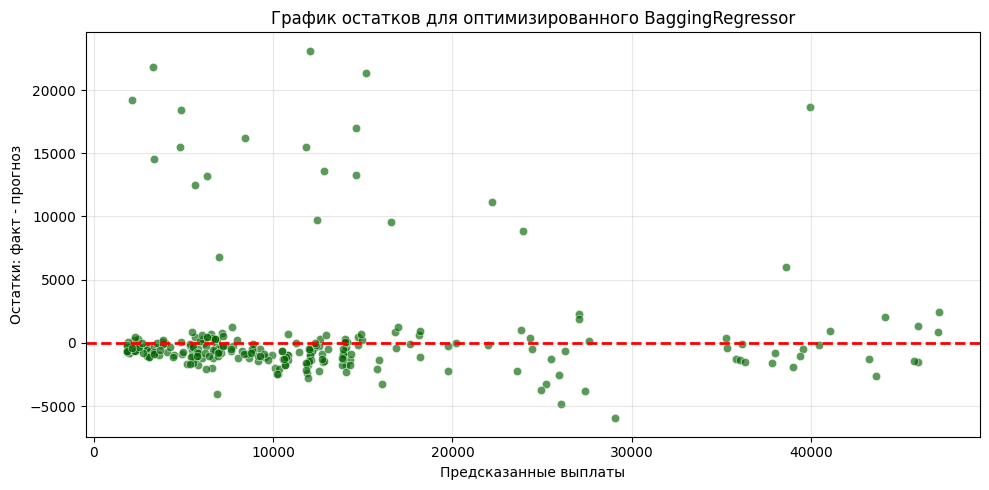

In [35]:
residuals = inverse_target(y_test) - inverse_target(y_test_pred)

plt.figure(figsize=(10, 5))
sns.scatterplot(x=inverse_target(y_test_pred), y=residuals, alpha=0.65, color='darkgreen')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('График остатков для оптимизированного BaggingRegressor')
plt.xlabel('Предсказанные выплаты')
plt.ylabel('Остатки: факт - прогноз')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'bagging_residuals_test.png', dpi=200, bbox_inches='tight')
plt.show()

# Случайный лес


## Базовая модель

In [36]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_val)
print(f"R2:   {r2_score(y_val, rf_pred):.4f}")
print(f"MAE:  ${mean_absolute_error(y_val, rf_pred):.2f}")
print(f"RMSE: ${root_mean_squared_error(y_val, rf_pred):.2f}")

R2:   0.8534
MAE:  $2391.80
RMSE: $4724.42


# Проведем двухэтапную оптимизацию по гиперпараметрам

Сначала используем широкую сетку, чтобы найти примерную область хороших значений. Затем строим более узкую сетку рядом с лучшими параметрами и повторяем поиск. Такой подход позволяет не перебирать слишком много вариантов сразу, но при этом точнее проверить область, где модель уже показала хороший результат.

In [37]:
rf_cv = KFold(n_splits=5, shuffle=True, random_state=42)

rf_coarse_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8, 10, 12, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf': [1, 4, 8],
    'max_features': ['sqrt', 0.7, 1.0],
    'bootstrap': [True],
    'ccp_alpha': [0.0, 0.0001]
}

rf_coarse_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_coarse_param_grid,
    scoring=r2_original_scorer,
    cv=rf_cv,
    n_jobs=-1,
    return_train_score=True
)

rf_coarse_grid_search.fit(X_train, y_train)
rf_coarse_best_params = rf_coarse_grid_search.best_params_

print('Лучшие параметры Random Forest после широкого поиска:')
print(rf_coarse_best_params)
print(f"Лучший средний R² после широкого поиска: {rf_coarse_grid_search.best_score_:.4f}")

def integer_values_around(best_value, radius, lower_bound, upper_bound):
    values = range(best_value - radius, best_value + radius + 1)
    return [int(value) for value in values if lower_bound <= value <= upper_bound]

def stepped_values_around(best_value, radius, step, lower_bound, upper_bound):
    values = range(best_value - radius, best_value + radius + 1, step)
    result = sorted({int(value) for value in values if lower_bound <= value <= upper_bound})
    if best_value not in result:
        result.append(int(best_value))
    return sorted(result)

def float_values_around(best_value, radius, lower_bound, upper_bound):
    values = [best_value - radius, best_value, best_value + radius]
    return sorted({round(value, 2) for value in values if lower_bound <= value <= upper_bound})

best_rf_depth = rf_coarse_best_params['max_depth']
if best_rf_depth is None:
    rf_refined_depths = [10, 12, 16, 20, None]
else:
    rf_refined_depths = integer_values_around(best_rf_depth, radius=2, lower_bound=1, upper_bound=30)

best_rf_max_features = rf_coarse_best_params['max_features']
if isinstance(best_rf_max_features, str):
    rf_refined_max_features = [best_rf_max_features, 0.5, 0.7]
else:
    rf_refined_max_features = float_values_around(best_rf_max_features, radius=0.1, lower_bound=0.3, upper_bound=1.0)

best_rf_alpha = rf_coarse_best_params['ccp_alpha']

rf_refined_param_grid = {
    'n_estimators': stepped_values_around(rf_coarse_best_params['n_estimators'], radius=50, step=50, lower_bound=50, upper_bound=400),
    'max_depth': rf_refined_depths,
    'min_samples_split': integer_values_around(rf_coarse_best_params['min_samples_split'], radius=2, lower_bound=2, upper_bound=60),
    'min_samples_leaf': integer_values_around(rf_coarse_best_params['min_samples_leaf'], radius=1, lower_bound=1, upper_bound=30),
    'max_features': rf_refined_max_features,
    'bootstrap': [rf_coarse_best_params['bootstrap']],
    'ccp_alpha': sorted({0.0, best_rf_alpha, best_rf_alpha * 10})
}

rf_refined_grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=rf_refined_param_grid,
    scoring=r2_original_scorer,
    cv=rf_cv,
    n_jobs=-1,
    return_train_score=True
)

rf_refined_grid_search.fit(X_train, y_train)

# Дальше используем результат уточненного поиска.
rf_grid_search = rf_refined_grid_search

best_rf_cv = rf_grid_search.best_estimator_
rf_val_pred_grid = best_rf_cv.predict(X_val)

print('\nЛучшие параметры Random Forest после уточненного поиска:')
print(rf_grid_search.best_params_)
print(f"Лучший средний R² после уточненного поиска: {rf_grid_search.best_score_:.4f}")
print('\nОптимизированный Random Forest на валидационной выборке')
print(f"R2:   {r2_score(y_val, rf_val_pred_grid):.4f}")
print(f"MAE:  ${mean_absolute_error(y_val, rf_val_pred_grid):.2f}")
print(f"RMSE: ${root_mean_squared_error(y_val, rf_val_pred_grid):.2f}")

rf_coarse_cv_results = pd.DataFrame(rf_coarse_grid_search.cv_results_)
rf_cv_results = pd.DataFrame(rf_refined_grid_search.cv_results_)
rf_cv_results[['mean_test_score', 'mean_train_score', 'params']].sort_values(
    by='mean_test_score',
    ascending=False
).head(10)


Лучшие параметры Random Forest после широкого поиска:
{'bootstrap': True, 'ccp_alpha': 0.0, 'max_depth': 6, 'max_features': 0.7, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Лучший средний R² после широкого поиска: 0.8458

Лучшие параметры Random Forest после уточненного поиска:
{'bootstrap': True, 'ccp_alpha': 0.0, 'max_depth': 6, 'max_features': 0.8, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Лучший средний R² после уточненного поиска: 0.8466

Оптимизированный Random Forest на валидационной выборке
R2:   0.8725
MAE:  $2042.81
RMSE: $4404.99


,mean_test_score,mean_train_score,params
154,0.846643,0.890437,"{'bootstrap': True, 'ccp_alpha': 0.0, 'max_dep..."
160,0.846643,0.890437,"{'bootstrap': True, 'ccp_alpha': 0.0, 'max_dep..."
157,0.846643,0.890437,"{'bootstrap': True, 'ccp_alpha': 0.0, 'max_dep..."
211,0.846582,0.902458,"{'bootstrap': True, 'ccp_alpha': 0.0, 'max_dep..."
208,0.846582,0.902458,"{'bootstrap': True, 'ccp_alpha': 0.0, 'max_dep..."
214,0.846582,0.902458,"{'bootstrap': True, 'ccp_alpha': 0.0, 'max_dep..."
145,0.846438,0.897198,"{'bootstrap': True, 'ccp_alpha': 0.0, 'max_dep..."
155,0.846428,0.890853,"{'bootstrap': True, 'ccp_alpha': 0.0, 'max_dep..."
158,0.846428,0.890853,"{'bootstrap': True, 'ccp_alpha': 0.0, 'max_dep..."
161,0.846428,0.890853,"{'bootstrap': True, 'ccp_alpha': 0.0, 'max_dep..."


## Финальная проверка случайного леса на тестовой выборке

После подбора гиперпараметров обучаем лучший случайный лес на объединенных тренировочной и валидационной выборках и проверяем его на отложенной тестовой выборке.


In [38]:
rf_train_full = pd.concat([X_train, X_val])
rf_y_train_full = pd.concat([y_train, y_val])

best_rf = clone(rf_grid_search.best_estimator_)
best_rf.fit(rf_train_full, rf_y_train_full)
rf_test_pred = best_rf.predict(X_test)

print('Финальная проверка оптимизированного Random Forest на тестовой выборке')
print(f"R2:   {r2_score(y_test, rf_test_pred):.4f}")
print(f"MAE:  ${mean_absolute_error(y_test, rf_test_pred):.2f}")
print(f"RMSE: ${root_mean_squared_error(y_test, rf_test_pred):.2f}")

joblib.dump(best_rf, models_dir / 'random_forest_gridsearch_model.pkl')
print('Модель сохранена:', models_dir / 'random_forest_gridsearch_model.pkl')


Финальная проверка оптимизированного Random Forest на тестовой выборке
R2:   0.8485
MAE:  $1964.76
RMSE: $4440.05
Модель сохранена: c:\Users\bulki\OneDrive\Документы\GitHub\Practice_DecisionTreeRegressor\models\random_forest_gridsearch_model.pkl


## Сравнение одиночного дерева, Bagging и случайного леса

Сравним одиночное дерево, оптимизированный `BaggingRegressor` и оптимизированный `RandomForestRegressor` на одной и той же тестовой выборке.


In [39]:
single_tree_model_path = models_dir / 'decision_tree_gridsearch_model.pkl'

if single_tree_model_path.exists():
    best_single_tree = joblib.load(single_tree_model_path)
else:
    best_single_tree = DecisionTreeRegressor(
        criterion='absolute_error',
        max_depth=6,
        min_samples_leaf=8,
        min_samples_split=2,
        random_state=42
    )
    best_single_tree.fit(X_train_full, y_train_full)

single_tree_test_pred = best_single_tree.predict(X_test)
single_tree_cv_scores = cross_val_score(
    clone(best_single_tree),
    X_train,
    y_train,
    scoring=r2_original_scorer,
    cv=cv,
    n_jobs=-1
)
single_tree_cv_r2 = single_tree_cv_scores.mean()

comparison_df = pd.DataFrame([
    {
        'Модель': 'Одиночное дерево решений',
        'R²': r2_score(y_test, single_tree_test_pred),
        'MAE': mean_absolute_error(y_test, single_tree_test_pred),
        'RMSE': root_mean_squared_error(y_test, single_tree_test_pred)
    },
    {
        'Модель': 'BaggingRegressor',
        'R²': r2_score(y_test, y_test_pred),
        'MAE': mean_absolute_error(y_test, y_test_pred),
        'RMSE': root_mean_squared_error(y_test, y_test_pred)
    },
    {
        'Модель': 'RandomForestRegressor',
        'R²': r2_score(y_test, rf_test_pred),
        'MAE': mean_absolute_error(y_test, rf_test_pred),
        'RMSE': root_mean_squared_error(y_test, rf_test_pred)
    }
])

comparison_df.sort_values(by='R²', ascending=False)


,Модель,R²,MAE,RMSE
2,RandomForestRegressor,0.848514,1964.758602,4440.047761
1,BaggingRegressor,0.847519,2010.778925,4454.604696
0,Одиночное дерево решений,0.839900,1723.630835,4564.536814


## Анализ результатов и выводы о снижении разброса

Сравнительный анализ построенных моделей на тестовой выборке показывает, как ансамблевые методы уменьшают разброс предсказаний:

1. **Изменение метрик:** переход от одиночного решающего дерева к ансамблевым методам позволяет повысить качество аппроксимации целевой переменной `charges`. Обычно коэффициент детерминации $R^2$ растет, а ошибки MAE и RMSE снижаются.
2. **Снижение разброса:** одиночное решающее дерево чувствительно к изменениям в обучающей выборке и может слишком глубоко подстраиваться под локальные особенности данных. Из-за этого на тестовой выборке его качество часто ниже, особенно в зоне дорогих страховых выплат.
3. **Bagging:** обучает много деревьев на bootstrap-подвыборках и усредняет их ответы. Усреднение снижает разброс предсказаний, поэтому модель становится устойчивее одиночного дерева.
4. **Случайный лес:** дополнительно выбирает случайное подмножество признаков при построении разбиений. Это делает деревья менее похожими друг на друга и может еще сильнее повысить устойчивость ансамбля.


## Сравнение OOB-оценки, кросс-валидации и тестовой выборки

OOB-оценка использует объекты, которые не попали в bootstrap-подвыборку для отдельных деревьев ансамбля. Сравним OOB R², R² на кросс-валидации и R² на тестовой выборке для одиночного дерева, Bagging и случайного леса. Для одиночного дерева OOB не применяется, потому что оно не строится на bootstrap-ансамбле.


In [40]:
bagging_oob = clone(grid_search.best_estimator_)
bagging_oob.set_params(oob_score=True)
bagging_oob.fit(X_train_full, y_train_full)

rf_oob = clone(rf_grid_search.best_estimator_)
rf_oob.set_params(oob_score=True, bootstrap=True)
rf_oob.fit(rf_train_full, rf_y_train_full)

bagging_oob_r2 = r2_score(y_train_full, bagging_oob.oob_prediction_)
rf_oob_r2 = r2_score(rf_y_train_full, rf_oob.oob_prediction_)

oob_comparison_df = pd.DataFrame([
    {
        'Модель': 'Одиночное дерево решений',
        'OOB R²': np.nan,
        'Кросс-валидация R²': single_tree_cv_r2,
        'Тест R²': r2_score(y_test, single_tree_test_pred),
        'Комментарий': 'OOB не применяется'
    },
    {
        'Модель': 'BaggingRegressor',
        'OOB R²': bagging_oob_r2,
        'Кросс-валидация R²': grid_search.best_score_,
        'Тест R²': r2_score(y_test, y_test_pred),
        'Комментарий': 'OOB рассчитан по bootstrap-ансамблю'
    },
    {
        'Модель': 'RandomForestRegressor',
        'OOB R²': rf_oob_r2,
        'Кросс-валидация R²': rf_grid_search.best_score_,
        'Тест R²': r2_score(y_test, rf_test_pred),
        'Комментарий': 'OOB рассчитан по bootstrap-ансамблю'
    }
])

oob_comparison_df


,Модель,OOB R²,Кросс-валидация R²,Тест R²,Комментарий
0,Одиночное дерево решений,NaN,0.831922,0.839900,OOB не применяется
1,BaggingRegressor,0.862818,0.847838,0.847519,OOB рассчитан по bootstrap-ансамблю
2,RandomForestRegressor,0.863713,0.846643,0.848514,OOB рассчитан по bootstrap-ансамблю


## Анализ OOB-валидации и итоги этапа

1. **OOB-оценка:** для Bagging и случайного леса OOB R² можно сравнить с кросс-валидацией и тестовой выборкой. Если значения близки, значит OOB дает похожую оценку обобщающей способности модели.
2. **Одиночное дерево:** для него OOB не считается, потому что OOB-оценка возникает только при bootstrap-обучении ансамбля. Поэтому для одиночного дерева ориентируемся на кросс-валидацию и тестовую выборку.
3. **Декорреляция базовых моделей:** случайный лес отличается от обычного Bagging тем, что на каждом разбиении использует случайное подмножество признаков. Это делает деревья менее похожими друг на друга и помогает снижать разброс.

**Итог этапа:** ансамблевые модели позволяют сгладить резкие ошибки одиночного дерева и снизить разброс предсказаний.

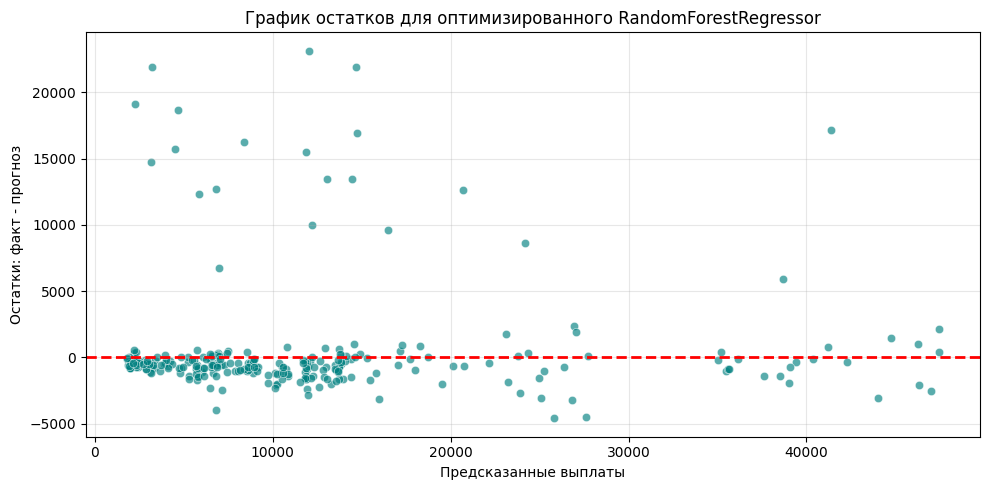

In [41]:
rf_residuals = inverse_target(y_test) - inverse_target(rf_test_pred)

plt.figure(figsize=(10, 5))
sns.scatterplot(x=inverse_target(rf_test_pred), y=rf_residuals, alpha=0.65, color='teal')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.title('График остатков для оптимизированного RandomForestRegressor')
plt.xlabel('Предсказанные выплаты')
plt.ylabel('Остатки: факт - прогноз')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(figures_dir / 'random_forest_residuals_test.png', dpi=200, bbox_inches='tight')
plt.show()


# Важность признаков

# Случайный лес

In [42]:
feature_importance_df = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность': best_rf.feature_importances_
}).sort_values(by='Важность', ascending=False)

feature_importance_df

,Признак,Важность
4,smoker_yes,0.518610
0,age,0.376330
1,bmi,0.050163
2,children,0.042318
3,sex_male,0.004243
5,region_northwest,0.003833
6,region_southeast,0.002576
7,region_southwest,0.001927


# Композиция деревьев

In [43]:
bagging_importances = np.mean(
    [tree.feature_importances_ for tree in best_bagging.estimators_],
    axis=0
)

bagging_importance_df = pd.DataFrame({
    'Признак': X_train.columns,
    'Важность': bagging_importances
}).sort_values(by='Важность', ascending=False)

bagging_importance_df

,Признак,Важность
4,smoker_yes,0.519968
0,age,0.384323
1,bmi,0.044151
2,children,0.042267
5,region_northwest,0.004290
3,sex_male,0.002729
7,region_southwest,0.001156
6,region_southeast,0.001116


Анализ важности признаков показал, что наибольшее влияние на стоимость медицинской страховки оказывает признак smoker. Это подтверждает выводы EDA: курящие клиенты имеют значительно более высокие значения charges. Также заметный вклад вносят bmi и age, так как индекс массы тела и возраст связаны с уровнем медицинских рисков. Остальные признаки, такие как sex, children и region, оказывают существенно меньшее влияние на прогноз модели.